In [23]:
import matplotlib.pyplot as plt
import numpy as np
from model_ranking.utils import load_h5, get_unique_colourmap

In [5]:
path_pred = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/consistency/P_full/Hm_model_Res1/norm_Normalize/none/predictions/test_predictions.h5"
path_pert_pred = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/consistency/P_full/Hm_model_Res1/norm_Normalize/gauss_a007-01/predictions/test_predictions.h5"

In [6]:
pred = load_h5(path_pred, "predictions")
pert_pred = load_h5(path_pert_pred, "predictions")

In [9]:
f1_score = load_h5(path_pred, "hard_f1")
consis_score = load_h5(path_pert_pred, "EI_consis")

In [11]:
consis_score.shape

(750,)

In [12]:
ids = (np.where(f1_score[:, 1] > 0.7) and (np.where(consis_score > 0.75) and np.where(consis_score < 0.85)))[0]

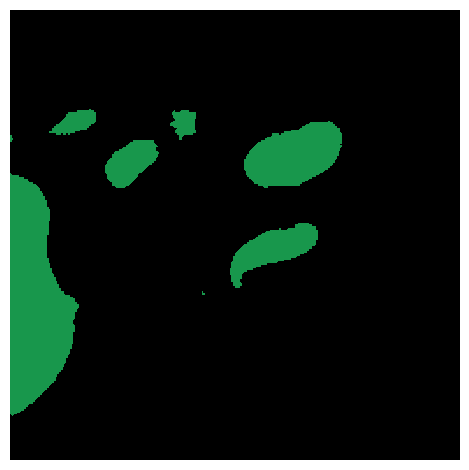

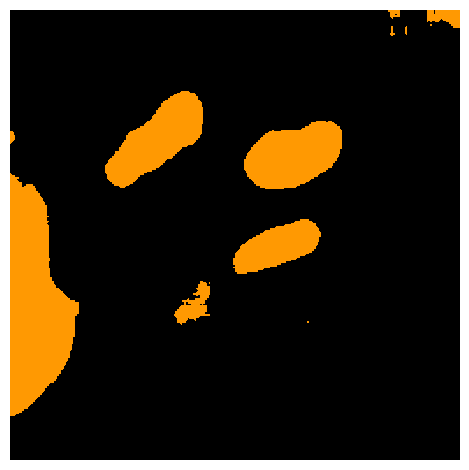

In [46]:
from matplotlib.colors import ListedColormap

hex_color1 = "#18974c"  # replace with your desired hex color
hex_color2 = "#ff9902"  # replace with your desired hex color
pred_cmap = ListedColormap(["black", hex_color1])
pert_pred_cmap = ListedColormap(["black", hex_color2])

i = ids[0]
pp = (pert_pred[i] > 0.5).squeeze()
p = (pred[i] > 0.5).squeeze()

_ = plt.imshow(p.astype(int), cmap=pred_cmap, vmin=0, vmax=1)
_ = plt.axis("off")
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/figures/HtoE_Res1_pred.png", bbox_inches="tight", pad_inches=0)
plt.show()

_ = plt.imshow(pp.astype(int), cmap=pert_pred_cmap, vmin=0, vmax=1)
_ = plt.axis("off")
plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/figures/HtoE_Res1_pert_pred.png", bbox_inches="tight", pad_inches=0)
plt.show()


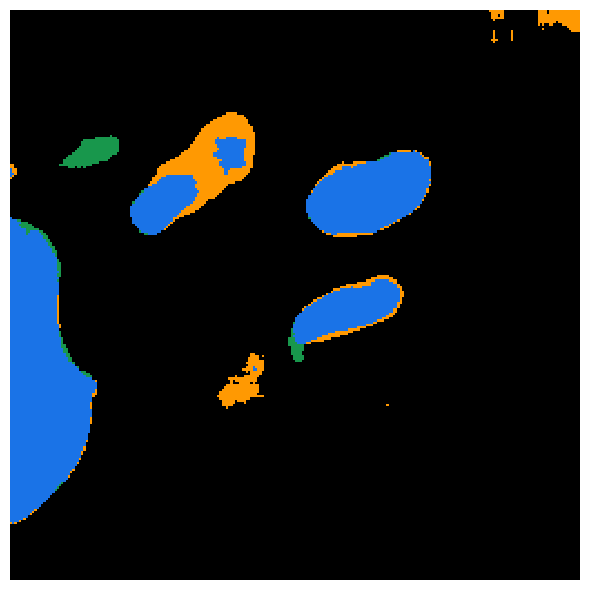

In [47]:
from matplotlib.colors import ListedColormap

hex_color3 = "#1a73e7"
overlay = np.zeros_like(p, dtype=np.uint8)
overlay[(pp == 1) & (p == 0)] = 1
overlay[(p == 1) & (pp == 0)] = 2
overlay[(p == 1) & (pp == 1)] = 3

overlay_cmap = ListedColormap(["black", hex_color2, hex_color1, hex_color3])

fig, ax = plt.subplots(figsize=(6, 6))
_ = ax.imshow(overlay, cmap=overlay_cmap, vmin=0, vmax=3, interpolation="nearest")
_ = ax.axis("off")



plt.tight_layout()
plt.savefig("/g/kreshuk/talks/model_ranking/figures/HtoE_Res1_overlay.png", bbox_inches="tight", pad_inches=0)
plt.show()
